In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [3]:
prices_raw_0 = pd.read_csv("prices_round_3_day_0.csv", sep = ";", index_col = "timestamp")
prices_raw_1 = pd.read_csv("prices_round_3_day_1.csv", sep = ";", index_col = "timestamp")
prices_raw_2 = pd.read_csv("prices_round_3_day_2.csv", sep = ";", index_col = "timestamp")

In [4]:
prices_raw_1.index = prices_raw_1.index + prices_raw_0.index.max() + 100
prices_raw_1

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
1000000,1,VELVETFRUIT_EXTRACT,5242,54,NaN,NaN,NaN,NaN,5248,54,NaN,NaN,NaN,NaN,5245.0,0.0
1000000,1,HYDROGEL_PACK,9950,13,9947.0,23.0,NaN,NaN,9966,13,9968.0,23.0,NaN,NaN,9958.0,0.0
1000000,1,VEV_6000,0,22,NaN,NaN,NaN,NaN,1,22,NaN,NaN,NaN,NaN,0.5,0.0
1000000,1,VEV_5000,248,19,NaN,NaN,NaN,NaN,254,6,255.0,13.0,NaN,NaN,251.0,0.0
1000000,1,VEV_6500,0,18,NaN,NaN,NaN,NaN,1,18,NaN,NaN,NaN,NaN,0.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999900,1,VEV_4000,1255,13,1252.0,21.0,NaN,NaN,1276,13,1279.0,21.0,NaN,NaN,1265.5,0.0
1999900,1,VEV_5100,175,23,NaN,NaN,NaN,NaN,180,23,NaN,NaN,NaN,NaN,177.5,0.0
1999900,1,VEV_5200,101,23,NaN,NaN,NaN,NaN,104,6,105.0,17.0,NaN,NaN,102.5,0.0


In [5]:
prices_raw_2.index = prices_raw_2.index + prices_raw_1.index.max() + 100
prices_raw_2

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
2000000,2,VEV_5200,102,21,NaN,NaN,NaN,NaN,106,21,NaN,NaN,NaN,NaN,104.0,0.0
2000000,2,VEV_5300,52,20,NaN,NaN,NaN,NaN,54,20,NaN,NaN,NaN,NaN,53.0,0.0
2000000,2,VEV_5000,267,7,266.0,14.0,NaN,NaN,273,7,274.0,14.0,NaN,NaN,270.0,0.0
2000000,2,VEV_4000,1257,15,1254.0,27.0,NaN,NaN,1278,15,1280.0,27.0,NaN,NaN,1267.5,0.0
2000000,2,VEV_5100,177,7,176.0,14.0,NaN,NaN,181,7,182.0,14.0,NaN,NaN,179.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999900,2,VELVETFRUIT_EXTRACT,5293,25,5292.0,39.0,NaN,NaN,5298,64,NaN,NaN,NaN,NaN,5295.5,0.0
2999900,2,VEV_4500,787,10,785.0,17.0,NaN,NaN,804,10,806.0,17.0,NaN,NaN,795.5,0.0
2999900,2,VEV_5400,19,28,NaN,NaN,NaN,NaN,21,28,NaN,NaN,NaN,NaN,20.0,0.0


In [6]:
prices_raw = pd.concat([prices_raw_0, prices_raw_1, prices_raw_2], axis=0)
prices_raw

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999900,2,VELVETFRUIT_EXTRACT,5293,25,5292.0,39.0,NaN,NaN,5298,64,NaN,NaN,NaN,NaN,5295.5,0.0
2999900,2,VEV_4500,787,10,785.0,17.0,NaN,NaN,804,10,806.0,17.0,NaN,NaN,795.5,0.0
2999900,2,VEV_5400,19,28,NaN,NaN,NaN,NaN,21,28,NaN,NaN,NaN,NaN,20.0,0.0


In [7]:
hgp = prices_raw[prices_raw["product"] == "HYDROGEL_PACK"]
hgp

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0
100,0,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0
200,0,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0
300,0,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,23.0,NaN,NaN,10002.0,0.0
400,0,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,23.0,NaN,NaN,10003.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999500,2,HYDROGEL_PACK,10002,11,10000.0,28.0,NaN,NaN,10018,11,10021.0,28.0,NaN,NaN,10010.0,0.0
2999600,2,HYDROGEL_PACK,10004,13,10001.0,30.0,NaN,NaN,10020,13,10022.0,30.0,NaN,NaN,10012.0,0.0
2999700,2,HYDROGEL_PACK,10004,13,10002.0,28.0,NaN,NaN,10020,13,10023.0,28.0,NaN,NaN,10012.0,0.0


<Axes: xlabel='timestamp'>

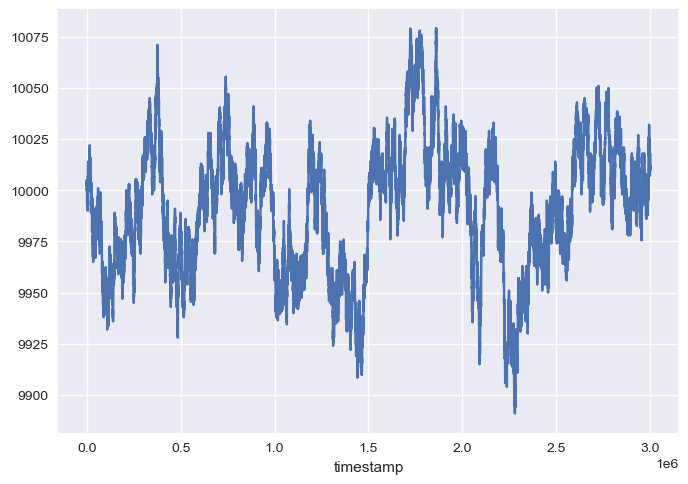

In [8]:
hgp = hgp.copy()
hgp["mid_price"].plot()

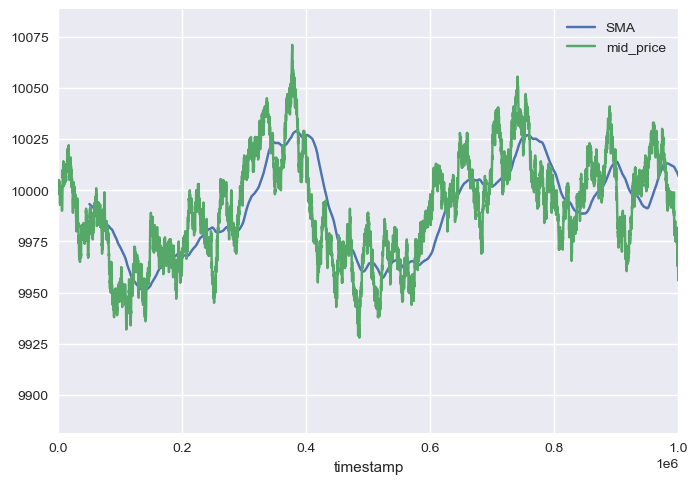

In [37]:
hgp["SMA"] = hgp["mid_price"].rolling(500).mean()
hgp[["SMA", "mid_price"]].plot(xlim=(0, 1000000))
hgp["residuals"] = hgp["mid_price"] - hgp["SMA"]

<Axes: xlabel='timestamp'>

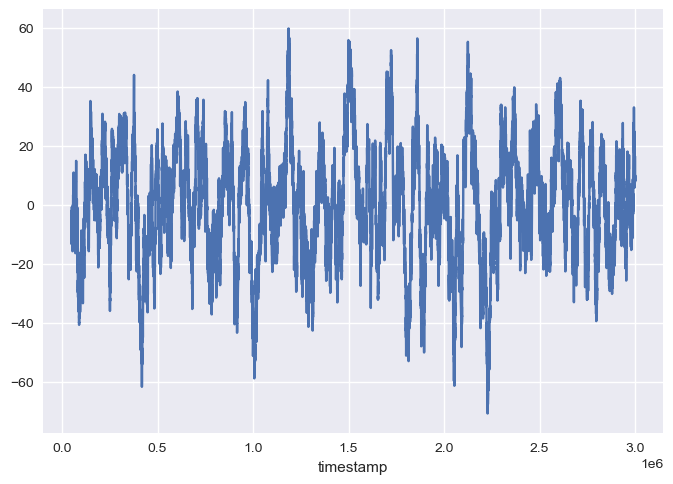

In [38]:
hgp["residuals"].plot()

In [39]:
hgp["residuals"].std()

19.28617275009289

In [10]:
import statsmodels.tsa.stattools as ts
adf, p_value, *_ = ts.adfuller(hgp["mid_price"])
p_value < 0.01, p_value

(np.True_, np.float64(1.0685013541258503e-05))

Reject null hypothesis of presence of unit root

In [11]:
print(hgp["mid_price"].mean())
print(hgp["mid_price"].std())

9990.806866666666
31.93521376335991


In [12]:
hgp

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,SMA
timestamp,,,,,,,,,,,,,,,,,
0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,NaN
100,0,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0,NaN
200,0,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0,NaN
300,0,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,23.0,NaN,NaN,10002.0,0.0,NaN
400,0,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,23.0,NaN,NaN,10003.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999500,2,HYDROGEL_PACK,10002,11,10000.0,28.0,NaN,NaN,10018,11,10021.0,28.0,NaN,NaN,10010.0,0.0,10013.800000
2999600,2,HYDROGEL_PACK,10004,13,10001.0,30.0,NaN,NaN,10020,13,10022.0,30.0,NaN,NaN,10012.0,0.0,10013.700000
2999700,2,HYDROGEL_PACK,10004,13,10002.0,28.0,NaN,NaN,10020,13,10023.0,28.0,NaN,NaN,10012.0,0.0,10013.500000
